# Lasso Regression

**Task**: Predict next-hour GK Volatility (`target_reg`)  
**Models**: Lasso Regression from scratch (Coordinate Descent) and sklearn  
**Evaluation**: Loss, R², Sparsity, Confusion Matrix, Accuracy, Precision, Sensitivity, Specificity, TNR, F1, ROC & AUC

---
## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# File paths
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_regression.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_regression.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'regression_results.csv')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

# compute regression metrics
def compute_metrics(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10)))) * 100
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  MSE     : {mse:.8f}")
    print(f"  RMSE    : {rmse:.8f}")
    print(f"  MAE     : {mae:.8f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE(%) : {mape:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'mse': round(mse,8), 'rmse': round(rmse,8),
            'mae': round(mae,8), 'r2': round(r2,4), 'mape': round(mape,4)}

# results to CSV
def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved → {RESULTS_CSV}")

# plot & save confusion matrix 
def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Low Vol','High Vol'], yticklabels=['Low Vol','High Vol'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print('Libraries loaded')
print(f'BASE_DIR    : {BASE_DIR}')
print(f'RESULTS_DIR : {RESULTS_DIR}')
print(f'PLOTS_DIR   : {PLOTS_DIR}')


Libraries loaded
BASE_DIR    : d:\ML\Project-Including model training\cryptoflow
RESULTS_DIR : d:\ML\Project-Including model training\cryptoflow\results
PLOTS_DIR   : d:\ML\Project-Including model training\cryptoflow\plots


In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['open time'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['open time'])

with open(FEATURES_FILE) as f:
    feature_cols = json.load(f)

if os.path.exists(SCALER_FILE):
    with open(SCALER_FILE, 'rb') as f:
        scaler = pickle.load(f)
    X_train = scaler.transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)
else:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)

y_train = train['target_reg'].values
y_test  = test['target_reg'].values

val_cut = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')


Train: 60,260 rows | Test: 10,635 rows
X_train: (60260, 10) | X_test: (10635, 10)
Features (10): ['hl_range_pct', 'gk_avg_6h', 'gk_lag_6h', 'hour_cos', 'gk_avg_3h', 'gk_lag_1h', 'trade_intensity', 'log_return_3h', 'log_return_6h', 'atr_lag_3h']


---
## 2. Data Analysis

=== Target Variable Statistics ===
              Train          Test
count  60260.000000  10635.000000
mean       0.006115      0.003886
std        0.005756      0.003113
min        0.000000      0.000229
25%        0.002852      0.001998
50%        0.004590      0.003076
75%        0.007497      0.004795
max        0.213448      0.085401


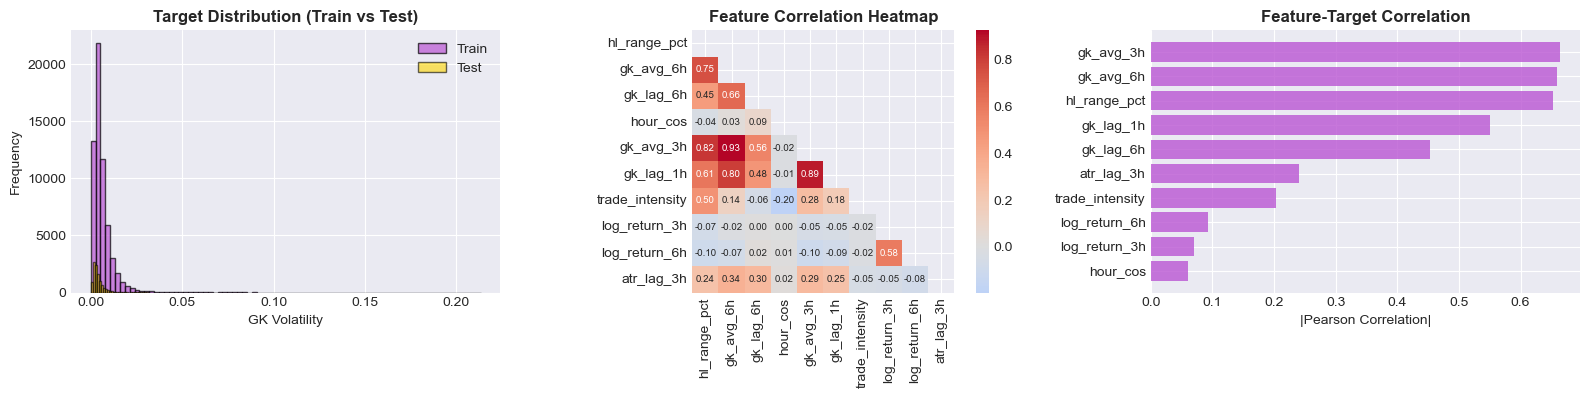

In [3]:
print('=== Target Variable Statistics ===')
print(pd.DataFrame({'Train': pd.Series(y_train).describe(),
                    'Test' : pd.Series(y_test).describe()}).round(8))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=80, alpha=0.7, color='mediumorchid', edgecolor='black', label='Train')
axes[0].hist(y_test,  bins=80, alpha=0.6, color='gold',         edgecolor='black', label='Test')
axes[0].set_xlabel('GK Volatility'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution (Train vs Test)', fontweight='bold')
axes[0].legend()

df_feat = pd.DataFrame(X_train, columns=feature_cols)
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

feat_target_corr = df_feat.corrwith(pd.Series(y_train)).abs().sort_values(ascending=True)
axes[2].barh(feat_target_corr.index, feat_target_corr.values, color='mediumorchid', alpha=0.8)
axes[2].set_xlabel('|Pearson Correlation|')
axes[2].set_title('Feature-Target Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Lasso Regression — From Scratch

Coordinate Descent + Soft-Thresholding

In [4]:
class LassoRegressionScratch:
    """Lasso Regression via Coordinate Descent + Soft-Thresholding."""
    def __init__(self, alpha=0.001, max_iter=1000, tol=1e-7, verbose=True):
        self.alpha        = alpha
        self.max_iter     = max_iter
        self.tol          = tol
        self.verbose      = verbose
        self.weights      = None
        self.bias         = None
        self.train_losses = []
        self.val_losses   = []
        self.n_nonzero    = []

    @staticmethod
    def _soft_threshold(rho, lam):
        if   rho >  lam: return rho - lam
        elif rho < -lam: return rho + lam
        else:            return 0.0

    def fit(self, X, y, X_val=None, y_val=None):
        n, p = X.shape
        self.weights      = np.zeros(p)
        self.bias         = 0.0
        self.train_losses = []
        self.val_losses   = []
        self.n_nonzero    = []
        col_norms_sq = (X ** 2).sum(axis=0)

        for iteration in range(self.max_iter):
            w_prev = self.weights.copy()
            residual = y - X @ self.weights
            self.bias = float(residual.mean())
            for j in range(p):
                r_j   = y - (X @ self.weights + self.bias) + X[:,j] * self.weights[j]
                rho_j = float(X[:,j] @ r_j)
                if col_norms_sq[j] == 0:
                    self.weights[j] = 0.0
                else:
                    self.weights[j] = self._soft_threshold(
                        rho_j / col_norms_sq[j],
                        self.alpha / col_norms_sq[j]
                    )
            y_pred = self.predict(X)
            mse    = float(np.mean((y_pred - y) ** 2))
            l1     = float(self.alpha * np.sum(np.abs(self.weights)))
            self.train_losses.append(mse + l1)
            self.n_nonzero.append(int((self.weights != 0).sum()))
            if X_val is not None:
                self.val_losses.append(float(np.mean((self.predict(X_val) - y_val) ** 2)))
            delta = float(np.max(np.abs(self.weights - w_prev)))
            if delta < self.tol:
                if self.verbose: print(f'  Converged at iteration {iteration+1} (delta={delta:.2e})')
                break
            if self.verbose and (iteration + 1) % 100 == 0:
                print(f'  Iter {iteration+1:4d}/{self.max_iter}  Loss={self.train_losses[-1]:.8f}  Non-zero={self.n_nonzero[-1]}')
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

    def get_coefficients(self, feature_names=None):
        names = feature_names or [f'x{i}' for i in range(len(self.weights))]
        return pd.Series(self.weights, index=names).sort_values(key=abs, ascending=False)

print('LassoRegressionScratch defined')


LassoRegressionScratch defined


---
## 4. Alpha Grid Search

=== Alpha Grid Search ===
  alpha=1e-05  val_MSE=0.00000796  non-zero=10/10
  alpha=5e-05  val_MSE=0.00000796  non-zero=10/10
  alpha=1e-04  val_MSE=0.00000796  non-zero=10/10
  alpha=5e-04  val_MSE=0.00000796  non-zero=10/10
  alpha=1e-03  val_MSE=0.00000796  non-zero=10/10
  alpha=5e-03  val_MSE=0.00000796  non-zero=10/10

Best alpha: 5e-03


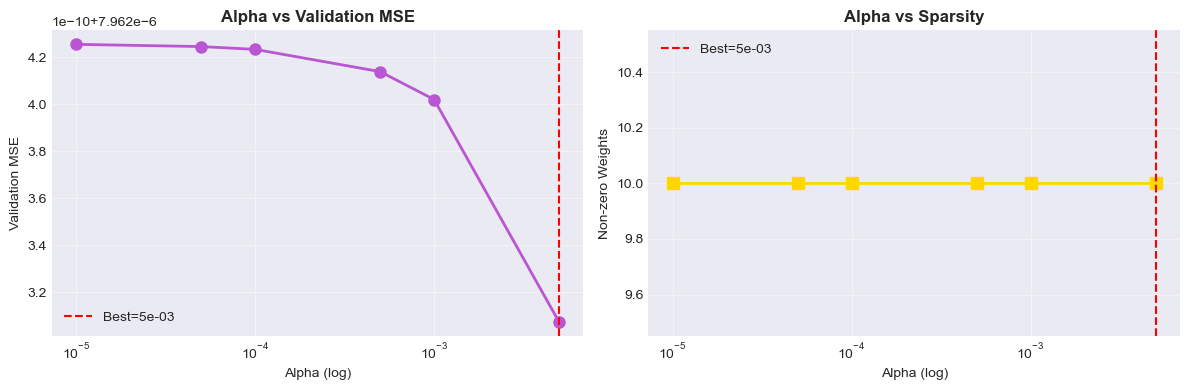

In [5]:
print('=== Alpha Grid Search ===')
alphas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]
alpha_results = []

for a in alphas:
    m = LassoRegressionScratch(alpha=a, max_iter=500, tol=1e-6, verbose=False)
    m.fit(X_tr, y_tr)
    val_mse = float(mean_squared_error(y_val, m.predict(X_val)))
    nnz     = int((m.weights != 0).sum())
    alpha_results.append({'alpha': a, 'val_mse': val_mse, 'non_zero': nnz})
    print(f'  alpha={a:.0e}  val_MSE={val_mse:.8f}  non-zero={nnz}/{len(feature_cols)}')

df_alpha   = pd.DataFrame(alpha_results)
best_alpha = float(df_alpha.loc[df_alpha['val_mse'].idxmin(), 'alpha'])
print(f'\nBest alpha: {best_alpha:.0e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx([r['alpha'] for r in alpha_results], [r['val_mse'] for r in alpha_results],
                  'o-', color='mediumorchid', lw=2, ms=8)
axes[0].axvline(best_alpha, color='red', ls='--', lw=1.5, label=f'Best={best_alpha:.0e}')
axes[0].set_xlabel('Alpha (log)'); axes[0].set_ylabel('Validation MSE')
axes[0].set_title('Alpha vs Validation MSE', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].semilogx([r['alpha'] for r in alpha_results], [r['non_zero'] for r in alpha_results],
                  's-', color='gold', lw=2, ms=8)
axes[1].axvline(best_alpha, color='red', ls='--', lw=1.5, label=f'Best={best_alpha:.0e}')
axes[1].set_xlabel('Alpha (log)'); axes[1].set_ylabel('Non-zero Weights')
axes[1].set_title('Alpha vs Sparsity', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_alpha_selection.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Train Lasso Models

In [6]:
print(f'=== Lasso Scratch (alpha={best_alpha:.0e}) ===')
lasso_scratch = LassoRegressionScratch(alpha=best_alpha, max_iter=1000, tol=1e-7, verbose=True)
lasso_scratch.fit(X_train, y_train, X_val=X_val, y_val=y_val)
y_pred_train_scratch = lasso_scratch.predict(X_train)
y_pred_test_scratch  = lasso_scratch.predict(X_test)
print(f'Non-zero weights: {(lasso_scratch.weights != 0).sum()} / {len(feature_cols)}')


=== Lasso Scratch (alpha=5e-03) ===
  Converged at iteration 80 (delta=9.41e-08)
Non-zero weights: 10 / 10


---
## 6. Lasso — sklearn

In [7]:
lasso_sk = Lasso(alpha=best_alpha, max_iter=10000)
lasso_sk.fit(X_train, y_train)
y_pred_train_sk = lasso_sk.predict(X_train)
y_pred_test_sk  = lasso_sk.predict(X_test)
print(f'sklearn non-zero: {(lasso_sk.coef_ != 0).sum()} / {len(feature_cols)}')

print('\nScratch vs sklearn R² comparison:')
print(f'  Scratch : {r2_score(y_test, y_pred_test_scratch):.4f}')
print(f'  sklearn : {r2_score(y_test, y_pred_test_sk):.4f}')


sklearn non-zero: 0 / 10

Scratch vs sklearn R² comparison:
  Scratch : 0.3683
  sklearn : -0.5125


---
## 7. Loss & Regression Metrics

In [8]:
models_pred = {
    f'Lasso (scratch, a={best_alpha:.0e})': (y_pred_train_scratch, y_pred_test_scratch),
    f'Lasso (sklearn, a={best_alpha:.0e})': (y_pred_train_sk,      y_pred_test_sk),
}

all_metrics = {}
for name, (y_tr_p, y_te_p) in models_pred.items():
    all_metrics[name] = compute_metrics(name, y_test, y_te_p)

for name, m in all_metrics.items():
    save_results(m)



  Lasso (scratch, a=5e-03)
  MSE     : 0.00000612
  RMSE    : 0.00247405
  MAE     : 0.00161484
  R²      : 0.3683
  MAPE(%) : 56.9642

  Lasso (sklearn, a=5e-03)
  MSE     : 0.00001466
  RMSE    : 0.00382842
  MAE     : 0.00319499
  R²      : -0.5125
  MAPE(%) : 153.0412
Results saved → d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv
Results saved → d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv


---
## 8. R² Score

=== R² Score Summary ===
  Lasso (scratch, a=5e-03)  Train=0.502498  Test=0.368346
  Lasso (sklearn, a=5e-03)  Train=0.000000  Test=-0.512528


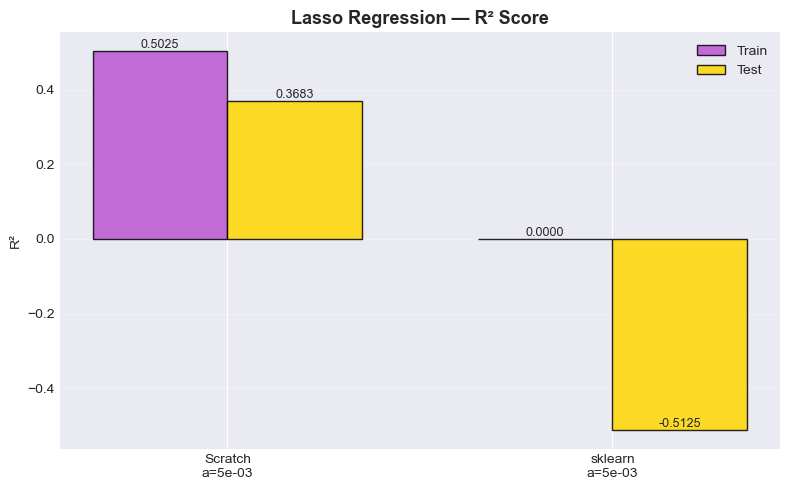

In [9]:
print('=== R² Score Summary ===')
for name, (y_tr_p, y_te_p) in models_pred.items():
    print(f'  {name}  Train={r2_score(y_train,y_tr_p):.6f}  Test={r2_score(y_test,y_te_p):.6f}')

short = [f'Scratch\na={best_alpha:.0e}', f'sklearn\na={best_alpha:.0e}']
r2_tr = [r2_score(y_train, v[0]) for v in models_pred.values()]
r2_te = [r2_score(y_test,  v[1]) for v in models_pred.values()]

x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x-w/2, r2_tr, w, label='Train', color='mediumorchid', alpha=0.85, edgecolor='black')
b2 = ax.bar(x+w/2, r2_te, w, label='Test',  color='gold',         alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('R²'); ax.set_title('Lasso Regression — R² Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in [(b,vv) for bars,vs in [(b1,r2_tr),(b2,r2_te)] for b,vv in zip(bars,vs)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_r2.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Performance Curves

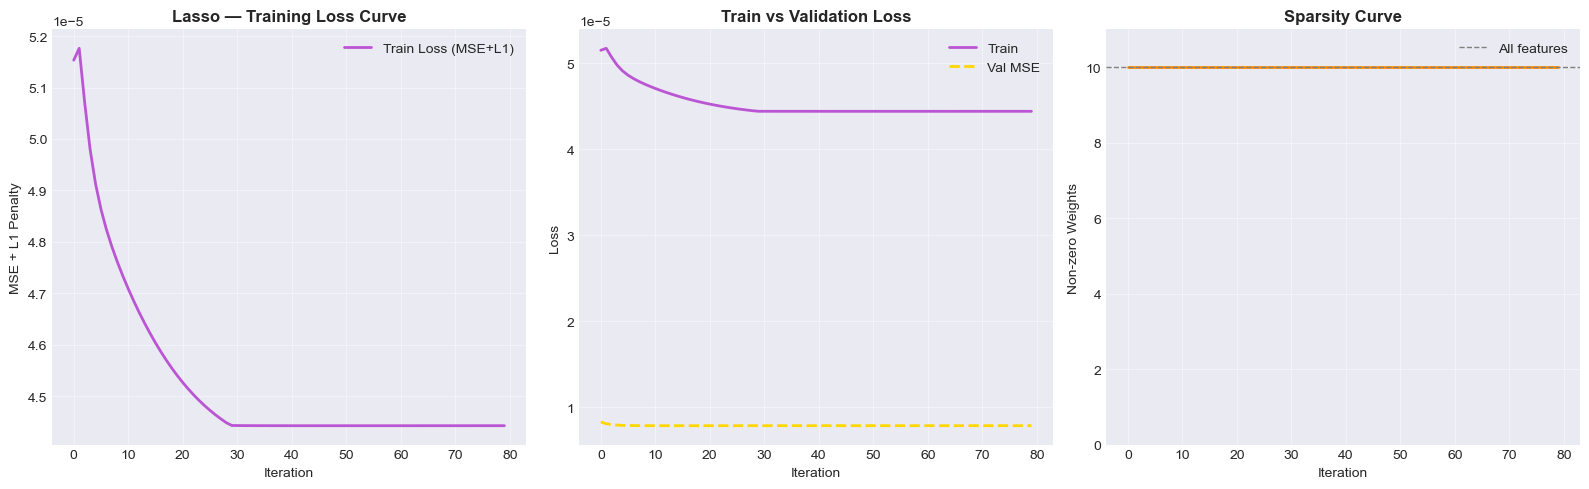

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(lasso_scratch.train_losses, color='mediumorchid', lw=2, label='Train Loss (MSE+L1)')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE + L1 Penalty')
axes[0].set_title('Lasso — Training Loss Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

if lasso_scratch.val_losses:
    n = len(lasso_scratch.val_losses)
    axes[1].plot(range(n), lasso_scratch.train_losses[:n], color='mediumorchid', lw=2, label='Train')
    axes[1].plot(range(n), lasso_scratch.val_losses, color='gold', lw=2, ls='--', label='Val MSE')
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Loss')
    axes[1].set_title('Train vs Validation Loss', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.4)

axes[2].plot(lasso_scratch.n_nonzero, color='darkorange', lw=2)
axes[2].axhline(len(feature_cols), color='gray', ls='--', lw=1, label='All features')
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Non-zero Weights')
axes[2].set_title('Sparsity Curve', fontweight='bold')
axes[2].set_ylim(0, len(feature_cols)+1); axes[2].legend(); axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_performance_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Coefficient Analysis

=== Lasso Coefficients ===
hl_range_pct       0.002285
gk_avg_6h          0.001596
hour_cos          -0.000402
gk_lag_6h          0.000349
trade_intensity   -0.000314
gk_lag_1h          0.000263
log_return_3h     -0.000149
log_return_6h     -0.000079
atr_lag_3h         0.000076
gk_avg_3h          0.000076

Non-zero (scratch): 10 / 10
Non-zero (sklearn): 0 / 10


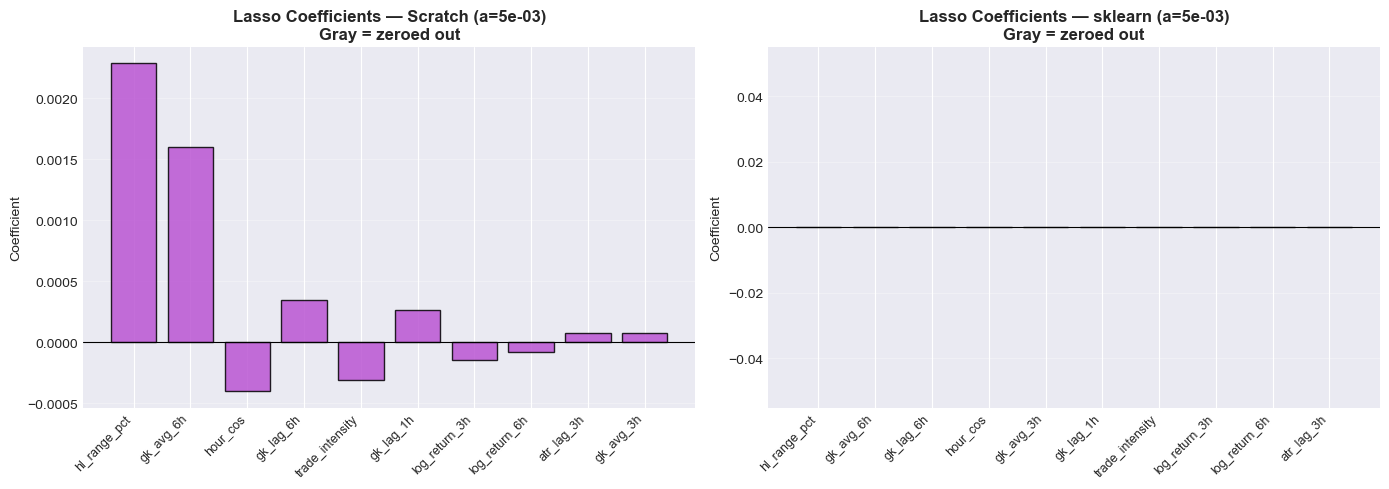

In [11]:
coefs_scratch = lasso_scratch.get_coefficients(feature_cols)
coefs_sk      = pd.Series(lasso_sk.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

print('=== Lasso Coefficients ===')
print(coefs_scratch.to_string())
print(f'\nNon-zero (scratch): {(coefs_scratch != 0).sum()} / {len(feature_cols)}')
print(f'Non-zero (sklearn): {(coefs_sk != 0).sum()} / {len(feature_cols)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coefs, title, color in [
    (axes[0], coefs_scratch, f'Scratch (a={best_alpha:.0e})', 'mediumorchid'),
    (axes[1], coefs_sk,      f'sklearn (a={best_alpha:.0e})', 'gold')
]:
    bar_colors = [color if v != 0 else 'lightgray' for v in coefs.values]
    ax.bar(coefs.index, coefs.values, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticklabels(coefs.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Coefficient'); ax.set_title(f'Lasso Coefficients — {title}\nGray = zeroed out', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Binarise Predictions for Classification Metrics

In [12]:
threshold = float(np.median(y_test))
print(f'Binarisation threshold (median GK): {threshold:.6f}')
y_true_bin = (y_test >= threshold).astype(int)

bin_results = {}
for name, (_, y_te_p) in models_pred.items():
    y_pred_bin = (y_te_p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    acc  = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    sens = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true_bin, y_te_p)
    roc_auc = auc(fpr, tpr)
    bin_results[name] = {
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Sensitivity(TPR)': round(sens,4), 'Specificity(TNR)': round(spec,4),
        'True Negative Rate': round(spec,4), 'F1-Score': round(f1,4),
        'AUC': round(roc_auc,4), '_fpr': fpr, '_tpr': tpr
    }

df_bin = pd.DataFrame({k:{kk:vv for kk,vv in v.items() if not kk.startswith('_')}
                        for k,v in bin_results.items()}).T
print('\n=== Binarised Classification Metrics ===')
print(df_bin.to_string())


Binarisation threshold (median GK): 0.003076

=== Binarised Classification Metrics ===
                              TP      TN      FP     FN  Accuracy  Precision  Sensitivity(TPR)  Specificity(TNR)  True Negative Rate  F1-Score     AUC
Lasso (scratch, a=5e-03)  4894.0  2321.0  2996.0  424.0    0.6784     0.6203            0.9203            0.4365              0.4365    0.7411  0.8378
Lasso (sklearn, a=5e-03)  5318.0     0.0  5317.0    0.0    0.5000     0.5000            1.0000            0.0000              0.0000    0.6667  0.5000


---
## 12. Confusion Matrix

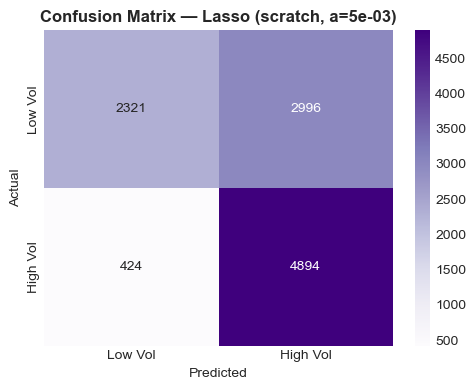

Saved: d:\ML\Project-Including model training\cryptoflow\plots\cm_lasso_Lasso_scratch_a5e-03.png


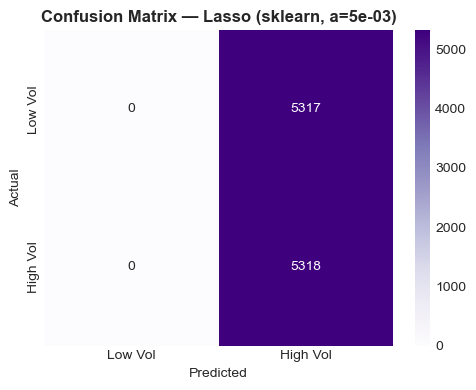

Saved: d:\ML\Project-Including model training\cryptoflow\plots\cm_lasso_Lasso_sklearn_a5e-03.png


In [13]:
for name, res in bin_results.items():
    y_pred_bin = (models_pred[name][1] >= threshold).astype(int)
    safe_name  = name.replace(' ', '_').replace('(', '').replace(')', '').replace('=','').replace(',','')
    plot_confusion_matrix(y_true_bin, y_pred_bin, name,
                          os.path.join(PLOTS_DIR, f'cm_lasso_{safe_name}.png'))


---
## 13. ROC Curve & AUC

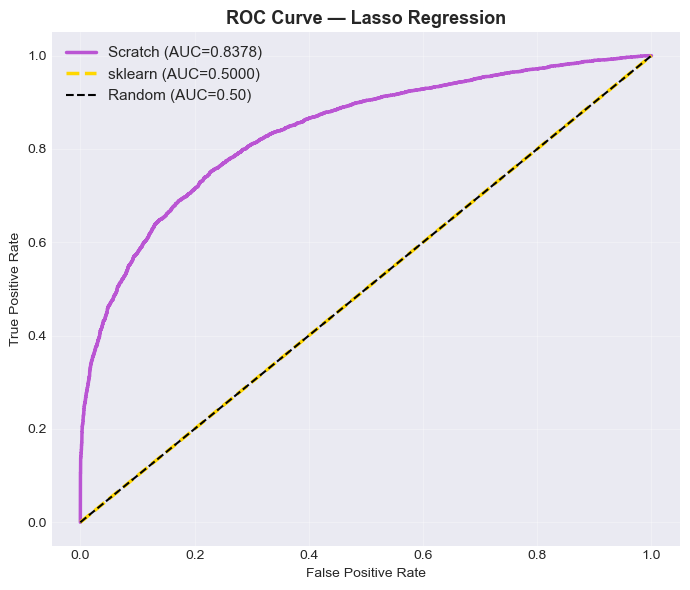

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['mediumorchid', 'gold']
styles = ['-', '--']

for (name, res), color, ls in zip(bin_results.items(), colors, styles):
    label = 'Scratch' if 'scratch' in name else 'sklearn'
    ax.plot(res['_fpr'], res['_tpr'], color=color, lw=2.5, ls=ls,
            label=f'{label} (AUC={res["AUC"]:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Lasso Regression', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 14. Classification Metric Charts

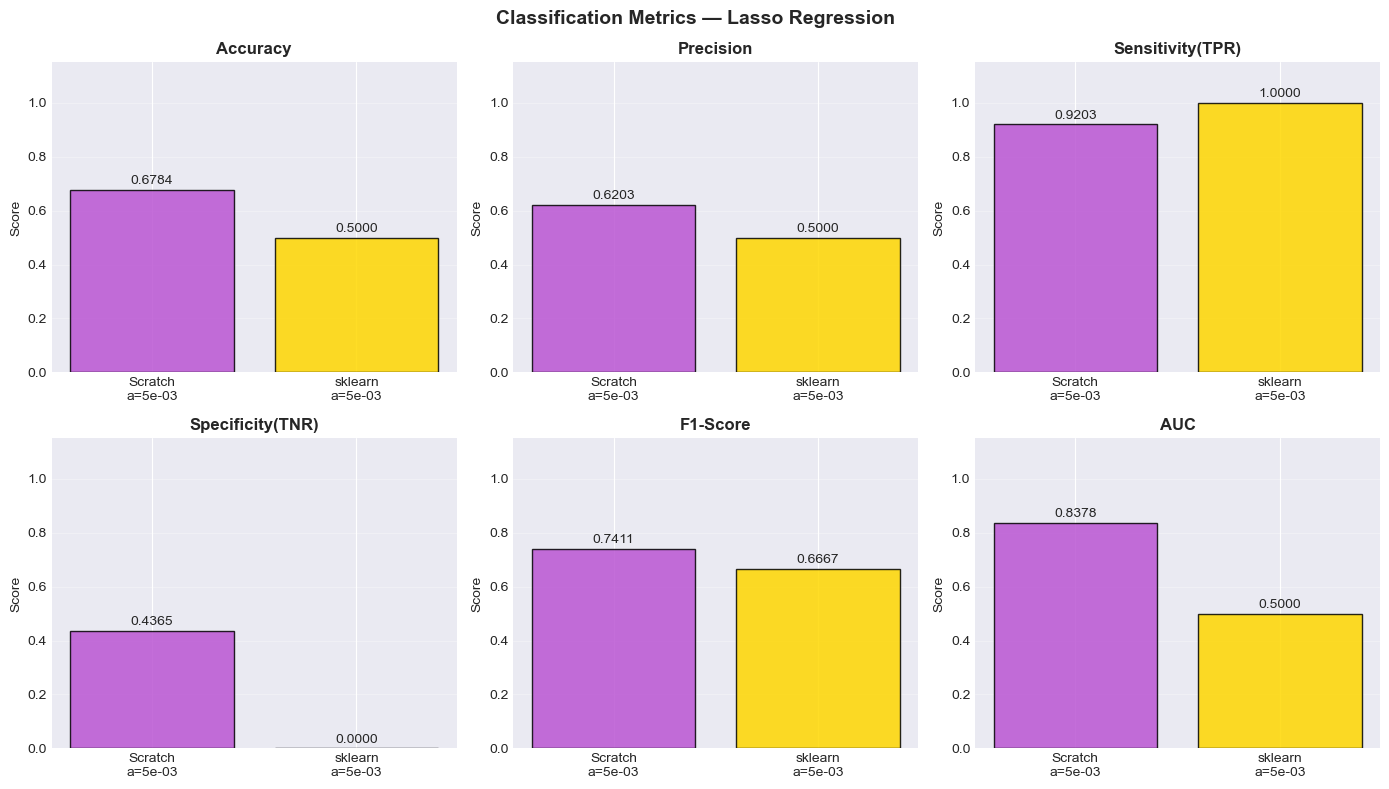

In [15]:
metrics_list = ['Accuracy','Precision','Sensitivity(TPR)','Specificity(TNR)','F1-Score','AUC']
short = [f'Scratch\na={best_alpha:.0e}', f'sklearn\na={best_alpha:.0e}']
palette = ['mediumorchid', 'gold']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_list):
    vals = [bin_results[m][metric] for m in bin_results]
    bars = ax.bar(short, vals, color=palette, edgecolor='black', alpha=0.85)
    ax.set_ylim(0, 1.15); ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Classification Metrics — Lasso Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_classification_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 15. Actual vs Predicted & Residual Analysis

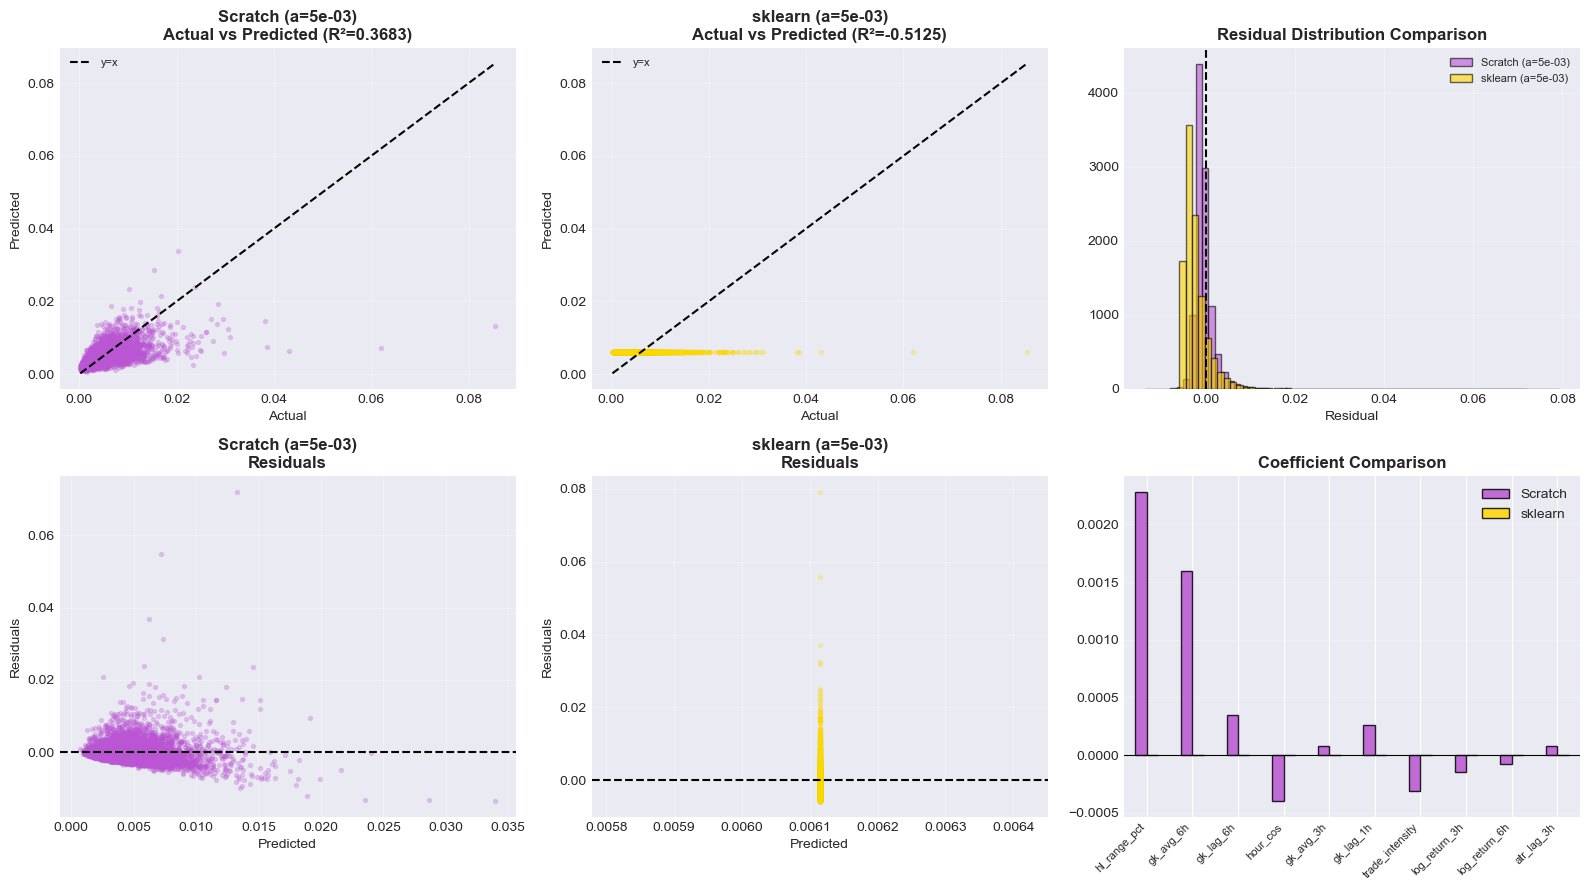

In [16]:
pred_list = [
    (f'Scratch (a={best_alpha:.0e})', y_pred_test_scratch, 'mediumorchid'),
    (f'sklearn (a={best_alpha:.0e})', y_pred_test_sk,      'gold'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, (title, y_pred, color) in enumerate(pred_list):
    axes[0,col].scatter(y_test, y_pred, alpha=0.25, s=8, color=color)
    mn, mx = min(y_test.min(),y_pred.min()), max(y_test.max(),y_pred.max())
    axes[0,col].plot([mn,mx],[mn,mx],'k--',lw=1.5,label='y=x')
    r2 = r2_score(y_test, y_pred)
    axes[0,col].set_title(f'{title}\nActual vs Predicted (R²={r2:.4f})', fontweight='bold')
    axes[0,col].set_xlabel('Actual'); axes[0,col].set_ylabel('Predicted')
    axes[0,col].legend(fontsize=8); axes[0,col].grid(alpha=0.3)

    res = y_test - y_pred
    axes[1,col].scatter(y_pred, res, alpha=0.25, s=8, color=color)
    axes[1,col].axhline(0, color='black', lw=1.5, ls='--')
    axes[1,col].set_title(f'{title}\nResiduals', fontweight='bold')
    axes[1,col].set_xlabel('Predicted'); axes[1,col].set_ylabel('Residuals')
    axes[1,col].grid(alpha=0.3)

for title, y_pred, color in pred_list:
    axes[0,2].hist(y_test - y_pred, bins=60, alpha=0.6, color=color, edgecolor='black', label=title)
axes[0,2].axvline(0, color='black', lw=1.5, ls='--')
axes[0,2].set_title('Residual Distribution Comparison', fontweight='bold')
axes[0,2].set_xlabel('Residual'); axes[0,2].legend(fontsize=8); axes[0,2].grid(alpha=0.3)

coef_df = pd.DataFrame({'Scratch': lasso_scratch.weights, 'sklearn': lasso_sk.coef_}, index=feature_cols)
coef_df.plot(kind='bar', ax=axes[1,2], color=['mediumorchid','gold'], edgecolor='black', alpha=0.85)
axes[1,2].axhline(0, color='black', lw=0.8)
axes[1,2].set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
axes[1,2].set_title('Coefficient Comparison', fontweight='bold')
axes[1,2].legend(); axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 16. Time-Series Prediction Plot

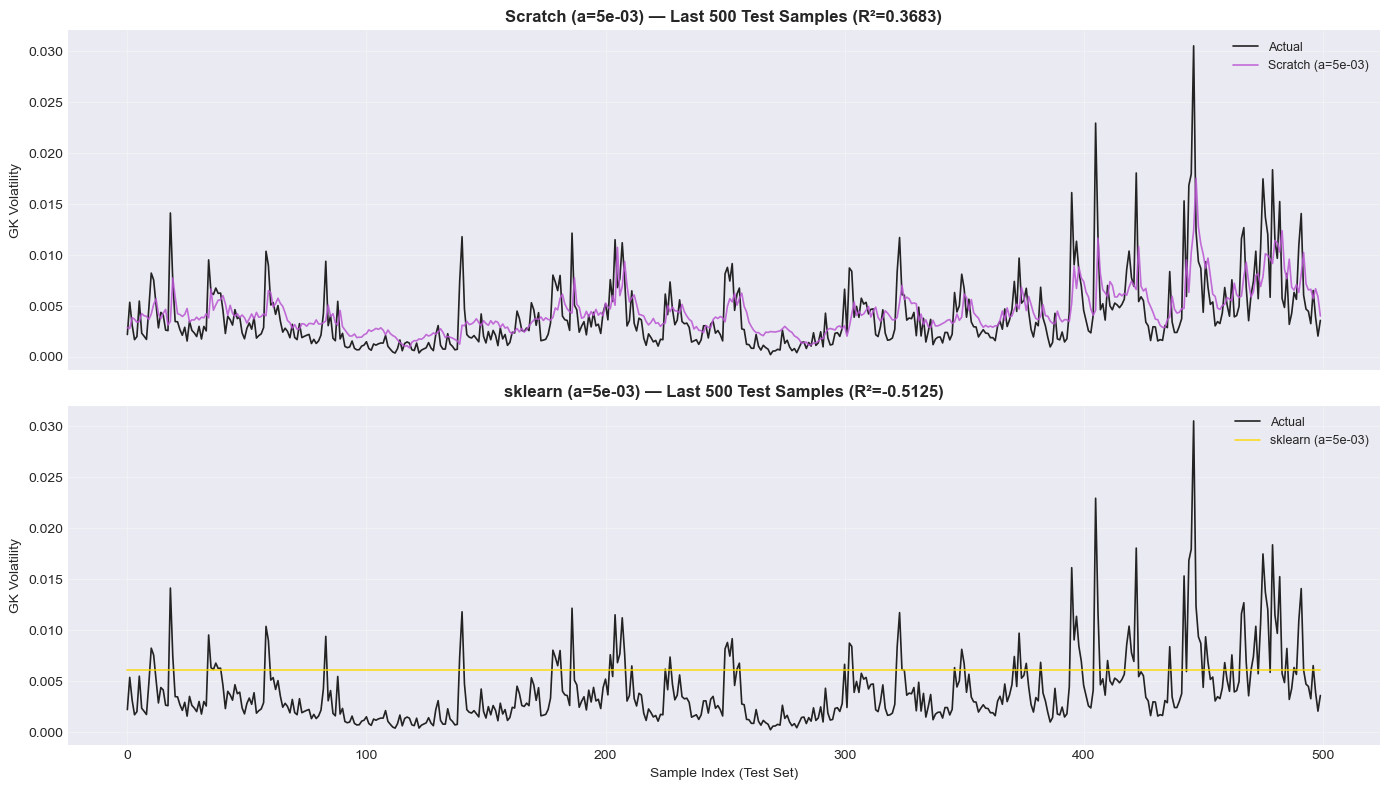

In [17]:
n_plot = 500
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (title, y_pred, color) in zip(axes, pred_list):
    ax.plot(range(n_plot), y_test[-n_plot:], color='black', lw=1.2, label='Actual', alpha=0.85)
    ax.plot(range(n_plot), y_pred[-n_plot:], color=color,   lw=1.2, label=title,   alpha=0.85)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title} — Last {n_plot} Test Samples (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('GK Volatility'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample Index (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lasso_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 17. Save & Load Models

In [18]:
with open(os.path.join(MODELS_DIR, 'lasso_scratch.pkl'), 'wb') as f: pickle.dump(lasso_scratch, f)
with open(os.path.join(MODELS_DIR, 'lasso_sklearn.pkl'), 'wb') as f: pickle.dump(lasso_sk,     f)
with open(os.path.join(MODELS_DIR, 'lasso_scaler.pkl'),  'wb') as f: pickle.dump(scaler,       f)
print('Models saved to:', MODELS_DIR)

with open(os.path.join(MODELS_DIR, 'lasso_scratch.pkl'), 'rb') as f: m = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'lasso_scaler.pkl'),  'rb') as f: s = pickle.load(f)
X_new = s.transform(test[feature_cols].values)
print(f'Load verification — R²: {r2_score(y_test, m.predict(X_new)):.6f}  OK')


Models saved to: d:\ML\Project-Including model training\cryptoflow\models
Load verification — R²: 0.368346  OK


---
## 18. Final Summary

In [19]:
print('='*65)
print('  LASSO REGRESSION — FINAL SUMMARY')
print('='*65)
print(f'Best alpha: {best_alpha:.0e}')
print(f'Non-zero (scratch): {(lasso_scratch.weights != 0).sum()} / {len(feature_cols)}')
print(f'Non-zero (sklearn): {(lasso_sk.coef_ != 0).sum()} / {len(feature_cols)}')
print('\n--- Regression Metrics (Test Set) ---')
for name, m in all_metrics.items():
    print(f'  {name}  MSE={m["mse"]:.6e}  RMSE={m["rmse"]:.6e}  R²={m["r2"]:.4f}')
print('\n--- Classification Metrics (Binarised at median GK) ---')
cols = ['Accuracy','Precision','Sensitivity(TPR)','Specificity(TNR)','F1-Score','AUC']
print(df_bin[cols].to_string())
print('='*65)
print(f'\nAll plots saved to : {PLOTS_DIR}')
print(f'Results saved to   : {RESULTS_CSV}')


  LASSO REGRESSION — FINAL SUMMARY
Best alpha: 5e-03
Non-zero (scratch): 10 / 10
Non-zero (sklearn): 0 / 10

--- Regression Metrics (Test Set) ---
  Lasso (scratch, a=5e-03)  MSE=6.120000e-06  RMSE=2.474050e-03  R²=0.3683
  Lasso (sklearn, a=5e-03)  MSE=1.466000e-05  RMSE=3.828420e-03  R²=-0.5125

--- Classification Metrics (Binarised at median GK) ---
                          Accuracy  Precision  Sensitivity(TPR)  Specificity(TNR)  F1-Score     AUC
Lasso (scratch, a=5e-03)    0.6784     0.6203            0.9203            0.4365    0.7411  0.8378
Lasso (sklearn, a=5e-03)    0.5000     0.5000            1.0000            0.0000    0.6667  0.5000

All plots saved to : d:\ML\Project-Including model training\cryptoflow\plots
Results saved to   : d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv
